# CNN — CIFAR-10 Adversarial Attacks
Baseline comparison for SNN adversarial robustness study on CIFAR-10.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# HYPERPARAMETERS & DATA
# ══════════════════════════════════════════════════════════════════════════════
CONFIG = {
    'batch_size' : 128,
    'lr'         : 1e-3,
    'num_epochs' : 60,
    'num_runs'   : 5,
}

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

cifar_train = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=train_tf)
cifar_test  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=test_tf)
train_loader = DataLoader(cifar_train, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(cifar_test,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

print(f"CIFAR-10 — Train: {len(cifar_train):,} | Test: {len(cifar_test):,}")

100%|██████████| 170M/170M [00:02<00:00, 79.0MB/s] 


CIFAR-10 — Train: 50,000 | Test: 10,000


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CNN ARCHITECTURE — VGG-style
# 3 conv blocks with BN + ReLU + MaxPool, then FC head
# This is the standard strong baseline for CIFAR-10
# ══════════════════════════════════════════════════════════════════════════════

class CNN_CIFAR(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: [3, 32, 32] → [64, 16, 16]
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  64, 3, padding=1, bias=False), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
        )
        # Block 2: [64, 16, 16] → [128, 8, 8]
        self.block2 = nn.Sequential(
            nn.Conv2d(64,  128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
        )
        # Block 3: [128, 8, 8] → [256, 4, 4]
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),
        )
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


model_test   = CNN_CIFAR().to(device)
out          = model_test(torch.zeros(4, 3, 32, 32).to(device))
total_params = sum(p.numel() for p in model_test.parameters())
print(f'Model output shape: {out.shape}  ✓  (expected: [4, 10])')
print(f'Total parameters: {total_params:,}')

Model output shape: torch.Size([4, 10])  ✓  (expected: [4, 10])
Total parameters: 3,250,122


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAINING & EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(imgs)
        loss   = criterion(output, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (output.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (model(imgs).argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return 100.0 * correct / total


print('Training and evaluation functions ready.')

Training and evaluation functions ready.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# MULTI-RUN TRAINING — 5 independent runs
# ══════════════════════════════════════════════════════════════════════════════

NUM_RUNS   = CONFIG['num_runs']
NUM_EPOCHS = CONFIG['num_epochs']

all_run_accs        = []
all_epoch_train_acc = []

print(f'Running {NUM_RUNS} independent experiments on CIFAR-10 ({NUM_EPOCHS} epochs each)')
print('=' * 65)

for run in range(NUM_RUNS):
    seed = 42 + run * 7
    torch.manual_seed(seed)
    np.random.seed(seed)

    model     = CNN_CIFAR().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'],
                                  betas=(0.9, 0.999), weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)
    criterion = nn.CrossEntropyLoss()
    epoch_train_accs = []

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        scheduler.step()
        epoch_train_accs.append(tr_acc)

        if epoch % 10 == 0 or epoch == NUM_EPOCHS:
            te_acc = evaluate(model, test_loader, device)
            print(f'Run {run+1}/5 | Epoch {epoch:2d}/{NUM_EPOCHS} | '
                  f'Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.1f}% | '
                  f'Test Acc: {te_acc:.1f}% | {time.time()-t0:.1f}s')

    final_acc = evaluate(model, test_loader, device)
    all_run_accs.append(final_acc)
    all_epoch_train_acc.append(epoch_train_accs)
    print(f'  → Run {run+1} Final Test Accuracy: {final_acc:.2f}%\n')


cnn_mean = np.mean(all_run_accs)
cnn_std  = np.std(all_run_accs)
print('=' * 65)
print(f'CNN CIFAR-10 RESULTS  ({NUM_RUNS} runs)')
print(f'  Accuracy : {cnn_mean:.2f}% ± {cnn_std:.2f}%')

Running 5 independent experiments on CIFAR-10 (60 epochs each)
Run 1/5 | Epoch 10/60 | Train Loss: 0.5465 | Train Acc: 81.1% | Test Acc: 84.8% | 21.1s
Run 1/5 | Epoch 20/60 | Train Loss: 0.3889 | Train Acc: 86.7% | Test Acc: 88.1% | 20.5s
Run 1/5 | Epoch 30/60 | Train Loss: 0.2903 | Train Acc: 90.2% | Test Acc: 90.1% | 20.7s
Run 1/5 | Epoch 40/60 | Train Loss: 0.2078 | Train Acc: 92.8% | Test Acc: 91.7% | 20.6s
Run 1/5 | Epoch 50/60 | Train Loss: 0.1447 | Train Acc: 95.0% | Test Acc: 92.1% | 20.4s
Run 1/5 | Epoch 60/60 | Train Loss: 0.1196 | Train Acc: 95.9% | Test Acc: 92.6% | 20.4s
  → Run 1 Final Test Accuracy: 92.62%

Run 2/5 | Epoch 10/60 | Train Loss: 0.5468 | Train Acc: 81.2% | Test Acc: 85.3% | 20.8s
Run 2/5 | Epoch 20/60 | Train Loss: 0.3855 | Train Acc: 87.0% | Test Acc: 88.7% | 20.7s
Run 2/5 | Epoch 30/60 | Train Loss: 0.2915 | Train Acc: 89.9% | Test Acc: 90.2% | 21.1s
Run 2/5 | Epoch 40/60 | Train Loss: 0.2102 | Train Acc: 92.8% | Test Acc: 91.8% | 20.6s
Run 2/5 | Epoch 50

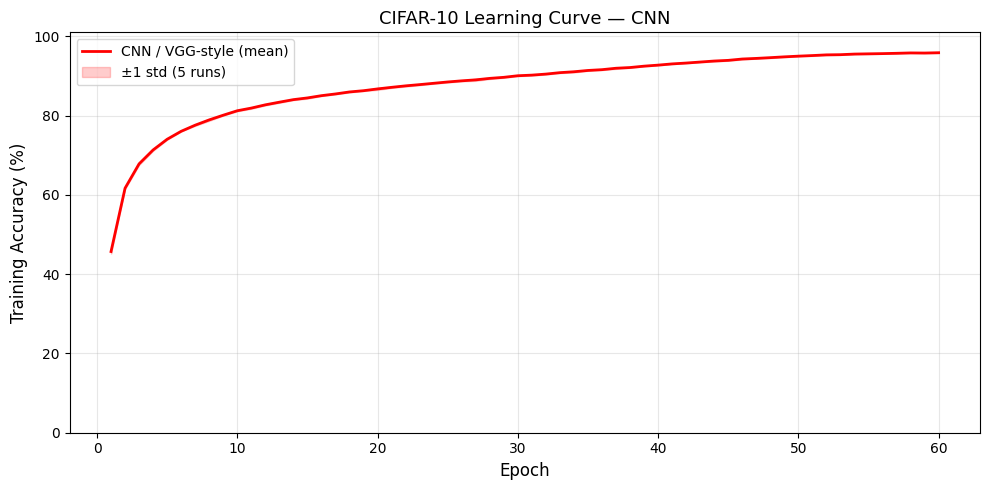

Figure saved: cnn_cifar10_learning_curve.png


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# LEARNING CURVE
# ══════════════════════════════════════════════════════════════════════════════

epochs_axis = list(range(1, NUM_EPOCHS + 1))
mean_curve  = np.mean(all_epoch_train_acc, axis=0)
std_curve   = np.std(all_epoch_train_acc,  axis=0)

plt.figure(figsize=(10, 5))
plt.plot(epochs_axis, mean_curve, 'r-', lw=2, label='CNN / VGG-style (mean)')
plt.fill_between(epochs_axis, mean_curve - std_curve, mean_curve + std_curve,
                 alpha=0.2, color='red', label='±1 std (5 runs)')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Accuracy (%)', fontsize=12)
plt.title('CIFAR-10 Learning Curve — CNN', fontsize=13)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.ylim(0, 101)
plt.tight_layout()
plt.savefig('cnn_cifar10_learning_curve.png', bbox_inches='tight')
plt.show()
print('Figure saved: cnn_cifar10_learning_curve.png')

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# ATTACK FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

_mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1,3,1,1).to(device)
_std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(1,3,1,1).to(device)
_lb   = (0.0 - _mean) / _std
_ub   = (1.0 - _mean) / _std

def clamp_normalized(x):
    return torch.max(torch.min(x, _ub), _lb)


def fgsm_attack(model, image, labels, epsilon):
    """Fast Gradient Sign Method"""
    adv_image = image.clone().detach().to(device)
    adv_image.requires_grad = True
    output = model(adv_image)
    loss   = F.cross_entropy(output, labels)
    model.zero_grad()
    loss.backward()
    with torch.no_grad():
        adv_image = adv_image + epsilon * adv_image.grad.sign()
        adv_image = clamp_normalized(adv_image)
    return adv_image.detach()


def pgd_attack(model, image, labels, epsilon, alpha=0.01, iters=10):
    """Projected Gradient Descent"""
    original_image = image.clone().detach().to(device)
    adv_image = image.clone().detach() + torch.empty_like(image).uniform_(-epsilon, epsilon)
    adv_image = clamp_normalized(adv_image).detach()
    for _ in range(iters):
        adv_image.requires_grad = True
        output = model(adv_image)
        loss   = F.cross_entropy(output, labels)
        model.zero_grad()
        loss.backward()
        with torch.no_grad():
            adv_image = adv_image + alpha * adv_image.grad.sign()
            eta       = torch.clamp(adv_image - original_image, min=-epsilon, max=epsilon)
            adv_image = clamp_normalized(original_image + eta)
        adv_image = adv_image.detach()
    return adv_image


print('FGSM and PGD Attack functions defined.')

FGSM and PGD Attack functions defined.


Running adversarial evaluation ...
Eps: 0.000 | FGSM: 73.2% | PGD: 74.8%
Eps: 0.010 | FGSM: 64.4% | PGD: 61.9%
Eps: 0.020 | FGSM: 51.3% | PGD: 49.1%
Eps: 0.050 | FGSM: 35.4% | PGD: 19.8%
Eps: 0.100 | FGSM: 24.9% | PGD: 2.3%


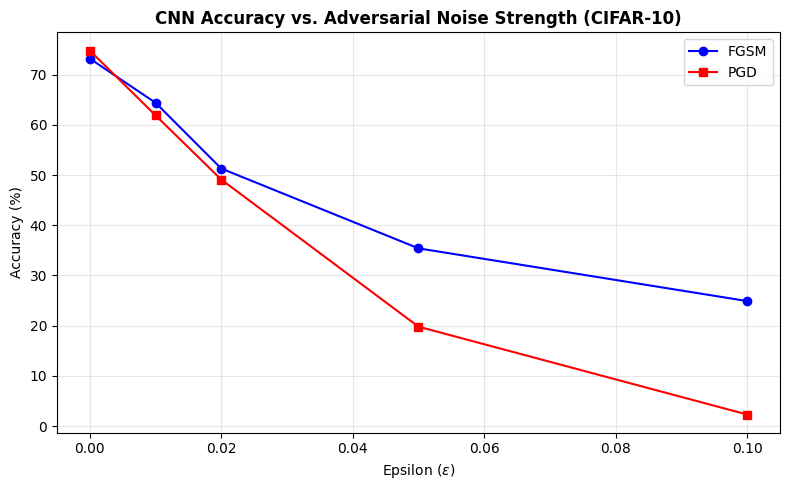

Figure saved: cnn_cifar10_robustness_curve.png


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# EPSILON SWEEP — same epsilons as SNN CIFAR notebook
# Model already loaded (best weights from training cell above)
# ══════════════════════════════════════════════════════════════════════════════

epsilons     = [0, 0.01, 0.02, 0.05, 0.1]
fgsm_accs, pgd_accs = [], []

# num_workers=0 avoids multiprocessing conflict with training DataLoaders
subset_loader = DataLoader(
    torch.utils.data.Subset(cifar_test, range(1000)), batch_size=64,
    num_workers=0, pin_memory=True)

print('Running adversarial evaluation ...')
for eps in epsilons:
    f_correct, p_correct, total = 0, 0, 0
    for imgs, labels in subset_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        adv_fgsm = fgsm_attack(model, imgs, labels, eps)
        adv_pgd  = pgd_attack(model, imgs, labels, eps,
                              alpha=eps/4 if eps > 0 else 0.01, iters=10)
        with torch.no_grad():
            f_correct += (model(adv_fgsm).argmax(1) == labels).sum().item()
            p_correct += (model(adv_pgd ).argmax(1) == labels).sum().item()
            total     += labels.size(0)
    fgsm_accs.append(100. * f_correct / total)
    pgd_accs.append(100. * p_correct / total)
    print(f'Eps: {eps:.3f} | FGSM: {fgsm_accs[-1]:.1f}% | PGD: {pgd_accs[-1]:.1f}%')

plt.figure(figsize=(8, 5))
plt.plot(epsilons, fgsm_accs, 'o-', label='FGSM', color='blue')
plt.plot(epsilons, pgd_accs,  's-', label='PGD',  color='red')
plt.title('CNN Accuracy vs. Adversarial Noise Strength (CIFAR-10)', fontweight='bold')
plt.xlabel('Epsilon ($\epsilon$)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_cifar10_robustness_curve.png', bbox_inches='tight')
plt.show()
print('Figure saved: cnn_cifar10_robustness_curve.png')


Generating Comprehensive Statistical Analysis (Epsilon: 0.02)...


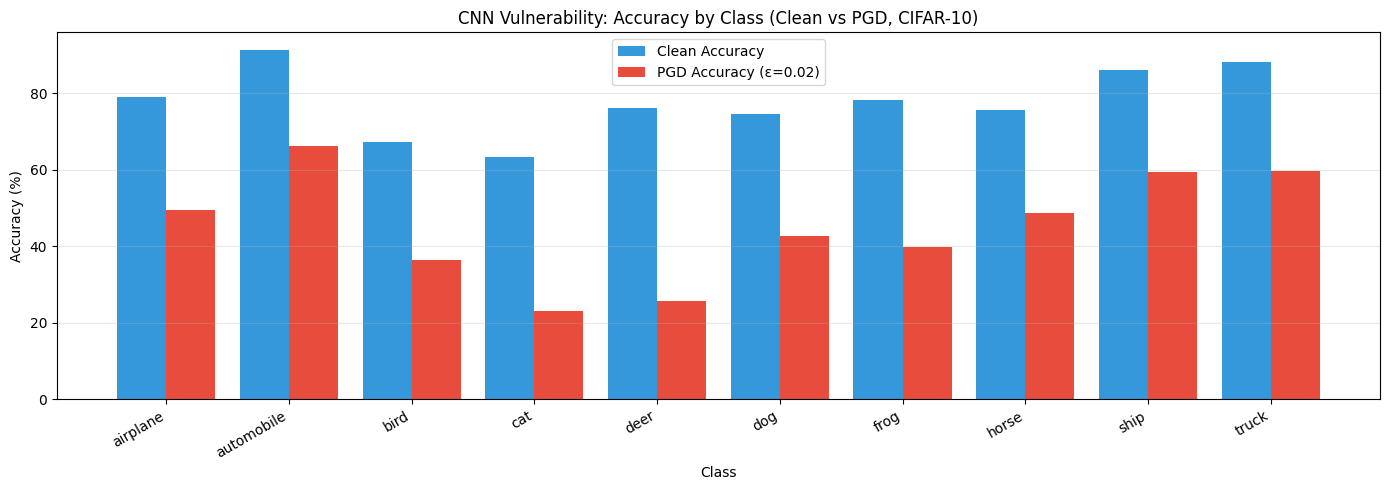

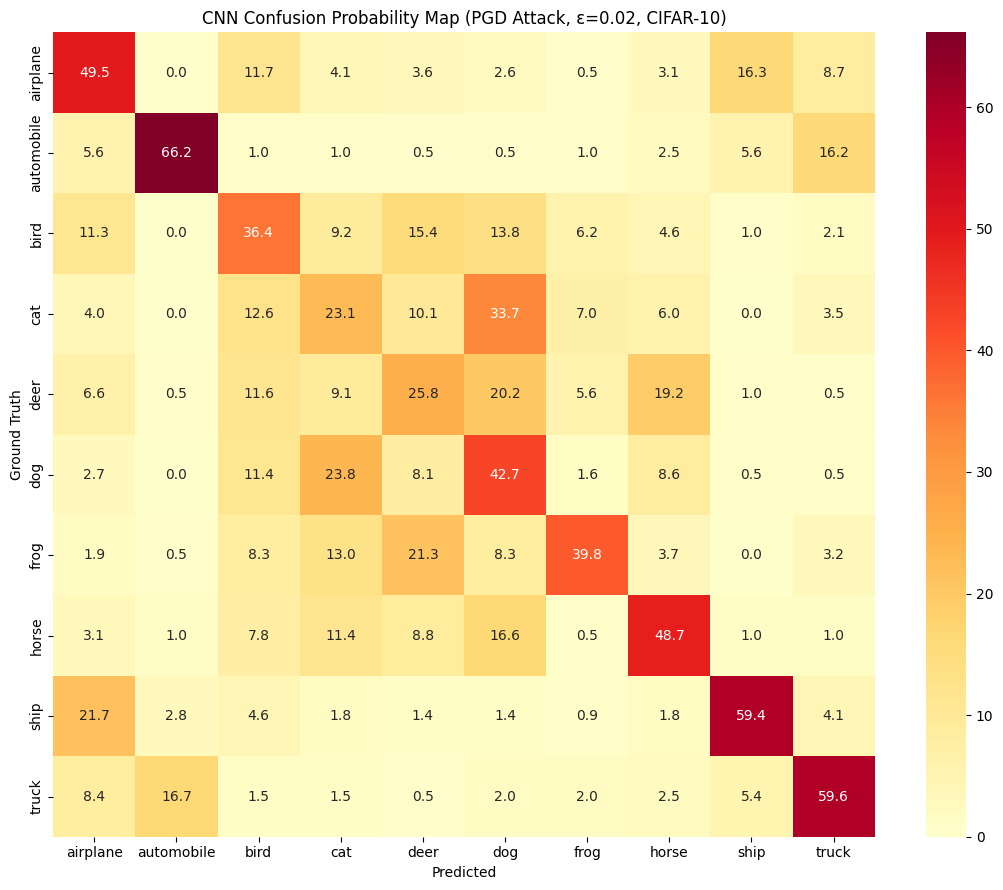


--- TOP 5 ADVERSARIAL MISCLASSIFICATIONS ---
         cat → dog         : 33.7% (67 instances)
        ship → airplane    : 21.7% (47 instances)
        frog → deer        : 21.3% (46 instances)
         dog → cat         : 23.8% (44 instances)
        deer → dog         : 20.2% (40 instances)


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE STATISTICAL ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

def denormalize(tensor):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)


def perform_final_analysis(model, dataset, epsilon, device):
    model.eval()
    y_true, y_pred_clean, y_pred_adv = [], [], []

    print(f'Generating Comprehensive Statistical Analysis (Epsilon: {epsilon})...')

    analysis_loader = DataLoader(
        torch.utils.data.Subset(dataset, range(min(2000, len(dataset)))), batch_size=64,
        num_workers=0)

    for imgs, labels in analysis_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.no_grad():
            y_pred_clean.extend(model(imgs).argmax(1).cpu().numpy())
        adv_imgs = pgd_attack(model, imgs, labels, epsilon,
                              alpha=epsilon/4 if epsilon > 0 else 0.01, iters=10)
        with torch.no_grad():
            y_pred_adv.extend(model(adv_imgs).argmax(1).cpu().numpy())
        y_true.extend(labels.cpu().numpy())

    y_true = np.array(y_true)

    # --- 1. Class-wise Accuracy Bar Chart ---
    cm_clean = confusion_matrix(y_true, y_pred_clean, labels=range(10))
    cm_adv   = confusion_matrix(y_true, y_pred_adv,   labels=range(10))
    acc_clean = cm_clean.diagonal() / (cm_clean.sum(axis=1) + 1e-10) * 100
    acc_adv   = cm_adv.diagonal()   / (cm_adv.sum(axis=1)   + 1e-10) * 100

    plt.figure(figsize=(14, 5))
    x = np.arange(10)
    plt.bar(x - 0.2, acc_clean, 0.4, label='Clean Accuracy',              color='#3498db')
    plt.bar(x + 0.2, acc_adv,   0.4, label=f'PGD Accuracy (ε={epsilon})', color='#e74c3c')
    plt.xlabel('Class')
    plt.ylabel('Accuracy (%)')
    plt.title('CNN Vulnerability: Accuracy by Class (Clean vs PGD, CIFAR-10)')
    plt.xticks(x, CIFAR10_CLASSES, rotation=30, ha='right')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('cnn_cifar10_classwise.png', bbox_inches='tight')
    plt.show()

    # --- 2. Confusion Probability Heatmap ---
    plt.figure(figsize=(11, 9))
    cm_perc = cm_adv.astype('float') / (cm_adv.sum(axis=1)[:, np.newaxis] + 1e-10) * 100
    sns.heatmap(cm_perc, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
    plt.title(f'CNN Confusion Probability Map (PGD Attack, ε={epsilon}, CIFAR-10)')
    plt.ylabel('Ground Truth')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig('cnn_cifar10_confusion.png', bbox_inches='tight')
    plt.show()

    # --- 3. Top 5 Adversarial Transitions ---
    errors = pd.DataFrame({'True': y_true, 'Pred': y_pred_adv})
    errors = errors[errors['True'] != errors['Pred']]
    top_confusions = errors.groupby(['True', 'Pred']).size().sort_values(ascending=False).head(5)
    print(f'\n--- TOP 5 ADVERSARIAL MISCLASSIFICATIONS ---')
    for (t, p), count in top_confusions.items():
        prob = (count / (y_true == t).sum()) * 100
        print(f"{CIFAR10_CLASSES[t]:>12} → {CIFAR10_CLASSES[p]:<12}: {prob:.1f}% ({count} instances)")


perform_final_analysis(model, cifar_test, epsilon=0.02, device=device)

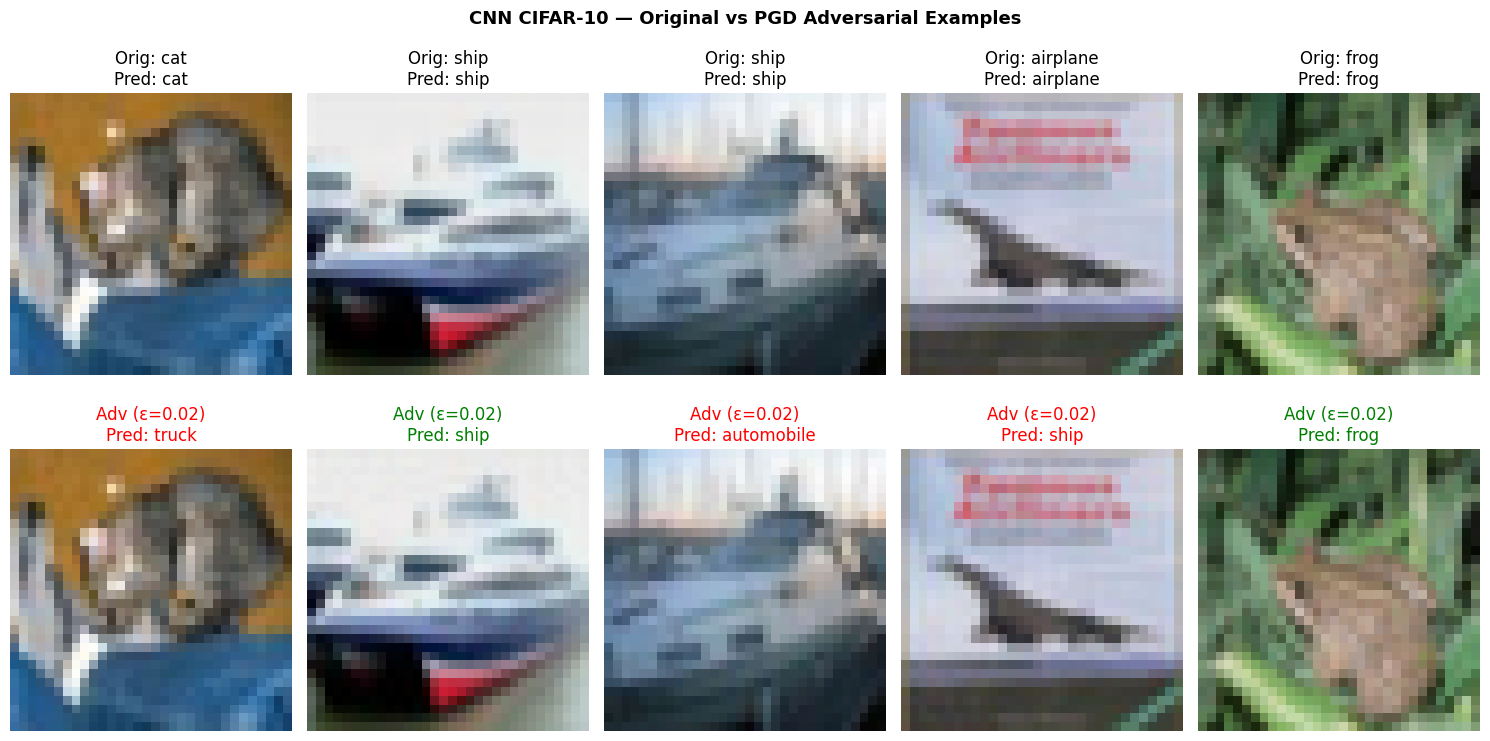

Figure saved: cnn_cifar10_adv_samples.png


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# ADVERSARIAL SAMPLE VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════

def visualize_adversarial_samples(model, loader, epsilon, device):
    # num_workers=0 to avoid multiprocessing conflict
    safe_loader = DataLoader(loader.dataset, batch_size=loader.batch_size,
                             shuffle=False, num_workers=0)
    imgs, labels = next(iter(safe_loader))
    imgs, labels = imgs.to(device), labels.to(device)
    adv_imgs = pgd_attack(model, imgs, labels, epsilon,
                          alpha=epsilon/4 if epsilon > 0 else 0.01, iters=15)
    with torch.no_grad():
        clean_preds = model(imgs).argmax(1)
        adv_preds   = model(adv_imgs).argmax(1)

    plt.figure(figsize=(15, 8))
    for i in range(5):
        plt.subplot(2, 5, i + 1)
        plt.imshow(denormalize(imgs[i]).permute(1, 2, 0))
        plt.title(f'Orig: {CIFAR10_CLASSES[labels[i]]}\nPred: {CIFAR10_CLASSES[clean_preds[i]]}')
        plt.axis('off')

        plt.subplot(2, 5, i + 6)
        plt.imshow(denormalize(adv_imgs[i]).permute(1, 2, 0))
        color = 'red' if adv_preds[i] != labels[i] else 'green'
        plt.title(f'Adv (ε={epsilon})\nPred: {CIFAR10_CLASSES[adv_preds[i]]}', color=color)
        plt.axis('off')

    plt.suptitle('CNN CIFAR-10 — Original vs PGD Adversarial Examples', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cnn_cifar10_adv_samples.png', bbox_inches='tight')
    plt.show()
    print('Figure saved: cnn_cifar10_adv_samples.png')


visualize_adversarial_samples(model, test_loader, epsilon=0.02, device=device)